# Complex Networks Assigmnent 1: Structural descriptors of complex networks

Maria Guasch Torres: maria.guasch.t@estudiantat.upc.edu

Andreu Garcies Ramon: andreu.garcies@estudiantat.upc.edu

In [3]:
from utils import *
from characterization import *
from models import *

## 1. Structural characterization

### 1.1. Macroscopic characterization


############ Characterization of net1.net ############
Number of nodes: 5000
Number of edges: 25000
Max degree: 16
Min degree: 6
Average degree: 10.0
Average clustering coefficient: 0.4141
Degree assortativity: -0.00973282948611821
Average shortest path length: 5.1211
Diameter: 8

############ Characterization of net2.net ############
Number of nodes: 5000
Number of edges: 24873
Max degree: 24
Min degree: 1
Average degree: 9.9492
Average clustering coefficient: 0.0021
Degree assortativity: -0.005662570648240358
Average shortest path length: 3.956
Diameter: 7

############ Characterization of net3.net ############
Number of nodes: 5000
Number of edges: 23508
Max degree: 732
Min degree: 3
Average degree: 9.4032
Average clustering coefficient: 0.0862
Degree assortativity: -0.1338595315237447
Average shortest path length: 3.0082
Diameter: 5

############ Characterization of net4.net ############
Number of nodes: 5000
Number of edges: 24975
Max degree: 210
Min degree: 5
Average degree: 9.9

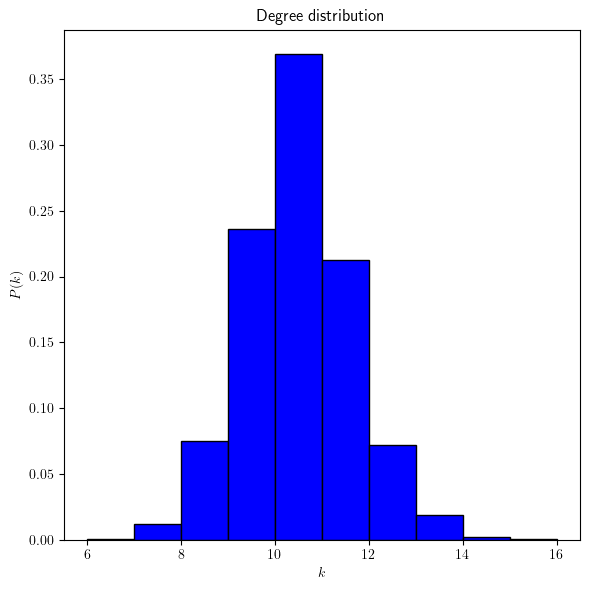

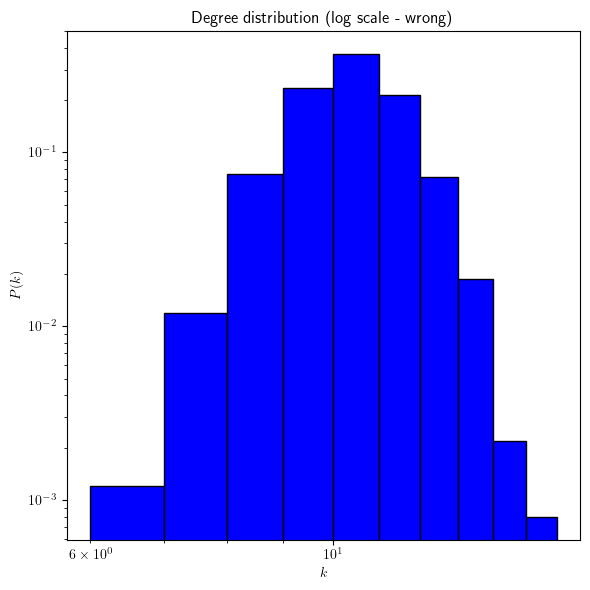

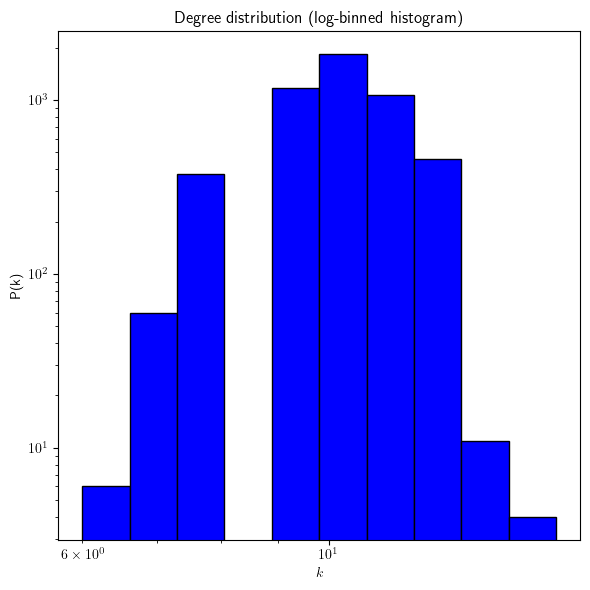

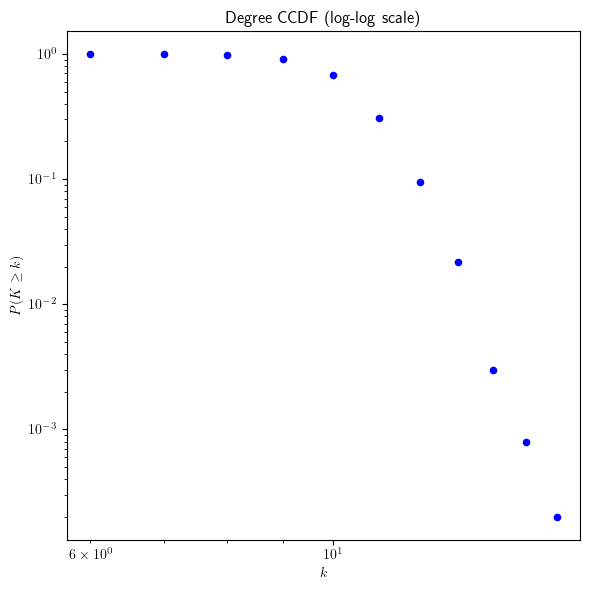

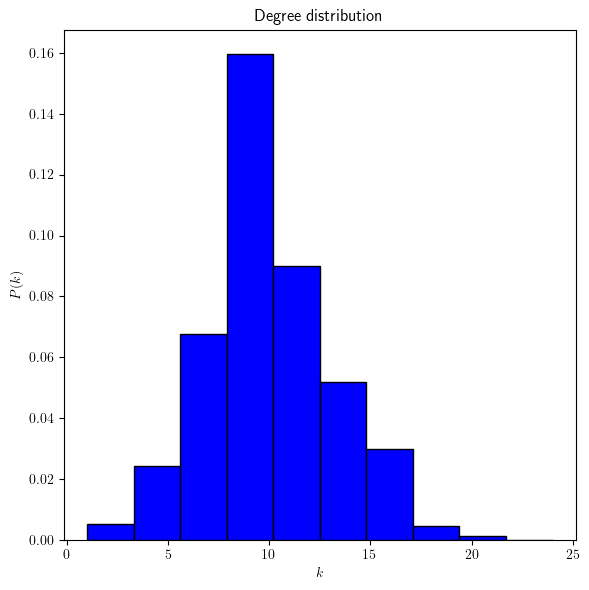

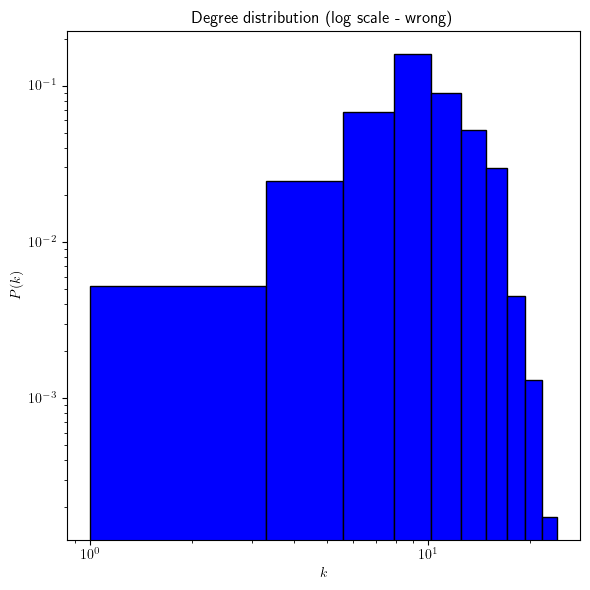

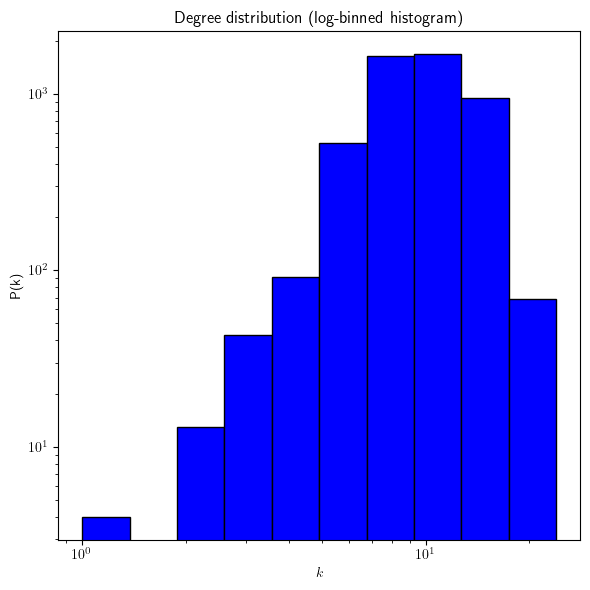

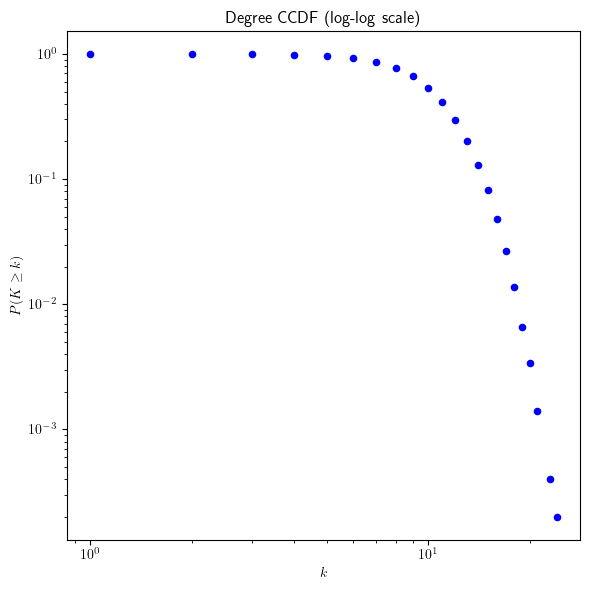

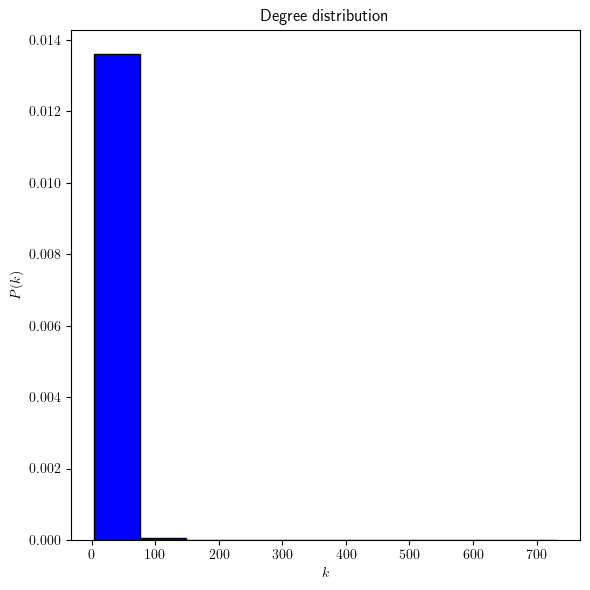

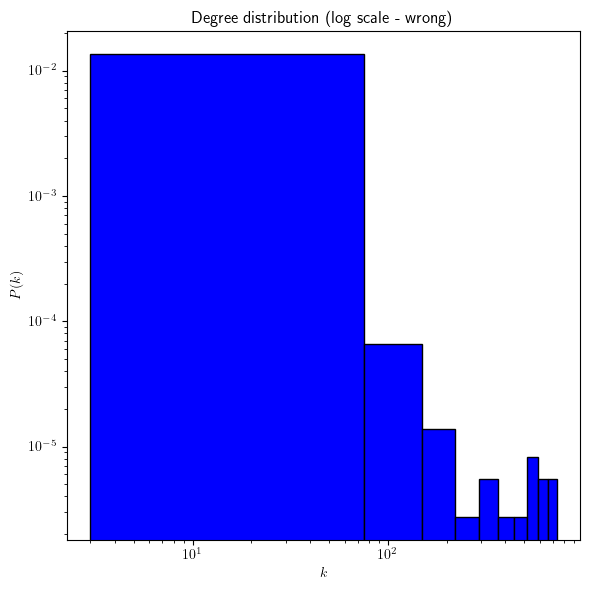

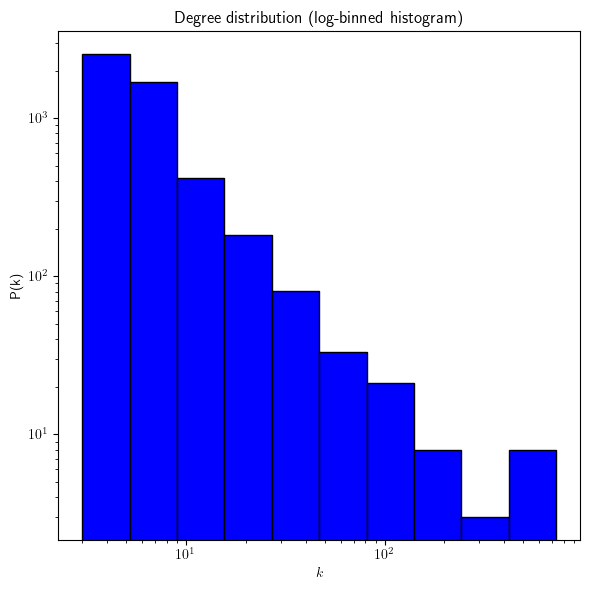

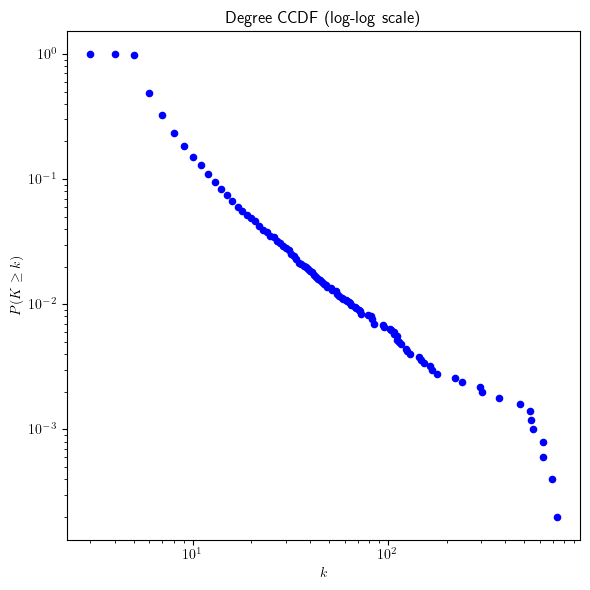

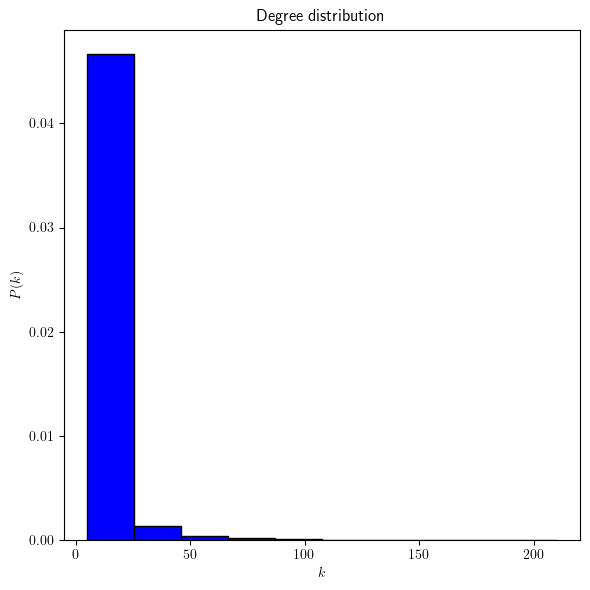

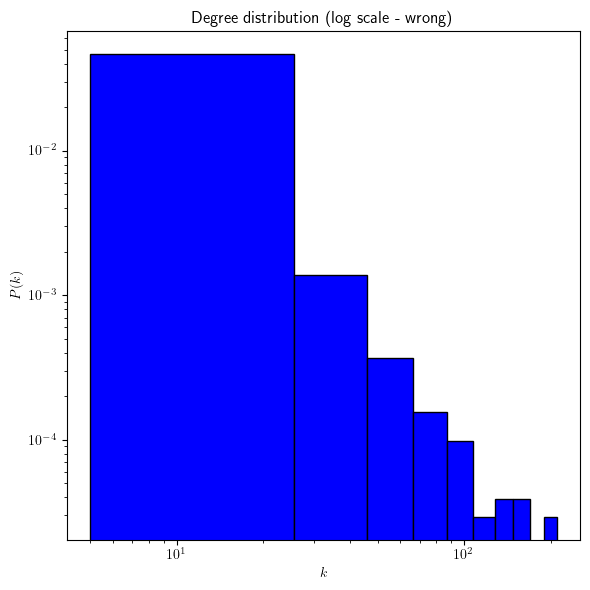

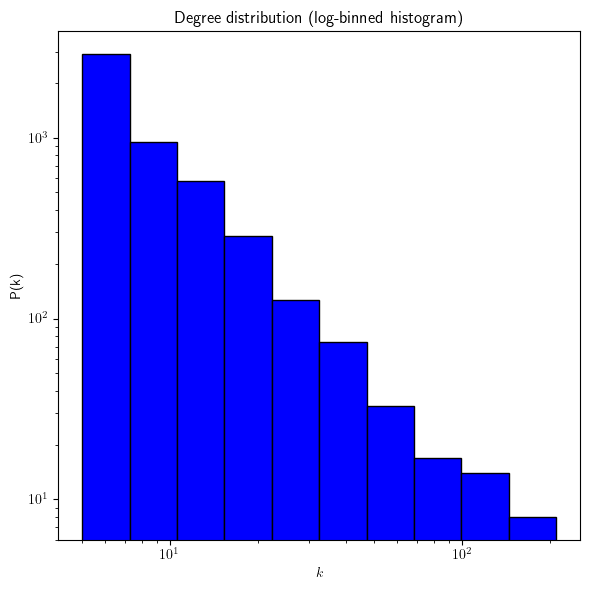

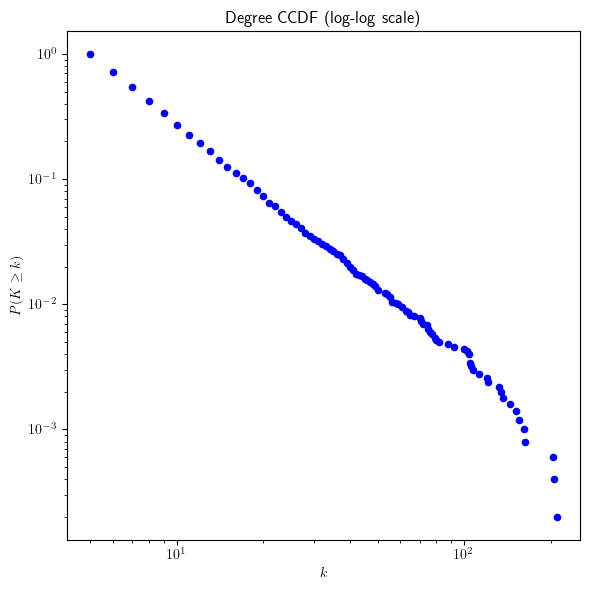

In [4]:
_ = characterize_network(load_network("net1.net"), "net1.net")
_ = characterize_network(load_network("net2.net"), "net2.net")
_ = characterize_network(load_network("net3.net"), "net3.net")
_ = characterize_network(load_network("net4.net"), "net4.net")

### 1.2. Microscopic characterization

In [5]:
_ = microscopic_description(load_network("net1.net"), "net1.net")
_ = microscopic_description(load_network("net2.net"), "net2.net")
_ = microscopic_description(load_network("net3.net"), "net3.net")
_ = microscopic_description(load_network("net4.net"), "net4.net")


############ Microscopic description of net1.net ############

Top 5 nodes by Degree Centrality:
  1693: 0.0032
  651: 0.0030
  1579: 0.0030
  4891: 0.0030
  41: 0.0028

Top 5 nodes by Betweenness Centrality:
  4747: 0.0041
  2645: 0.0040
  230: 0.0038
  4360: 0.0038
  1579: 0.0037

Top 5 nodes by Eigenvector Centrality:
  651: 0.0287
  1937: 0.0265
  4526: 0.0257
  4398: 0.0253
  1939: 0.0252

############ Microscopic description of net2.net ############

Top 5 nodes by Degree Centrality:
  1581: 0.0048
  787: 0.0046
  52: 0.0042
  1990: 0.0042
  2372: 0.0042

Top 5 nodes by Betweenness Centrality:
  1581: 0.0033
  787: 0.0026
  4382: 0.0025
  52: 0.0023
  2375: 0.0023

Top 5 nodes by Eigenvector Centrality:
  1581: 0.0412
  3233: 0.0344
  787: 0.0341
  2375: 0.0338
  131: 0.0336

############ Microscopic description of net3.net ############

Top 5 nodes by Degree Centrality:
  5: 0.1464
  7: 0.1382
  2: 0.1252
  0: 0.1240
  6: 0.1110

Top 5 nodes by Betweenness Centrality:
  5: 0.13

## 2. Models

### 2.1. Network 1: Watts-Strogatz

In [6]:
ws_simulation()

Generating Watts-Strogatz networks: 100%|██████████| 50/50 [09:05<00:00, 10.91s/it]

num_nodes: 5000.0000 ± 0.0000
num_edges: 25000.0000 ± 0.0000
max_degree: 15.2800 ± 0.8010
min_degree: 5.8000 ± 0.4000
avg_degree: 10.0000 ± 0.0000
avg_clustering: 0.4145 ± 0.0036
assortativity: -0.0133 ± 0.0060
aspl: 5.1207 ± 0.0172
diameter: 8.0000 ± 0.0000


Generating Watts-Strogatz networks and calculating metrics: 100%|██████████| 50/50 [04:26<00:00,  5.34s/it]


Estimated p from clustering: 0.15264179671752318
Estimated p from ASPL: 0.15264179671752318


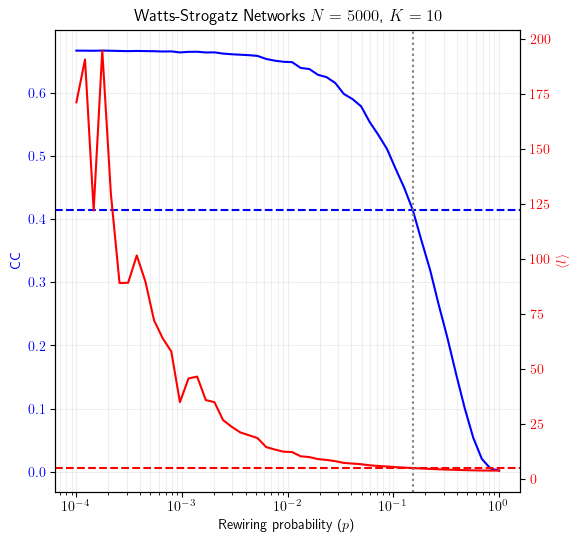

In [7]:
watts_strogatz_clustering_aspl()

### 2.2. Network 2: Erdös-Rényi Model

In [8]:
er_simulation()

Generating Erdös-Rényi networks: 100%|██████████| 50/50 [01:01<00:00,  1.24s/it]

12/50 generated ER networks were not connected.
num_nodes: 4999.7200 ± 0.5307
num_edges: 24873.0000 ± 0.0000
max_degree: 23.3600 ± 1.2611
min_degree: 1.1000 ± 0.3000
avg_degree: 9.9498 ± 0.0011
avg_clustering: 0.0020 ± 0.0002
assortativity: -0.0002 ± 0.0071
aspl: 3.9556 ± 0.0012
diameter: 6.7800 ± 0.4142


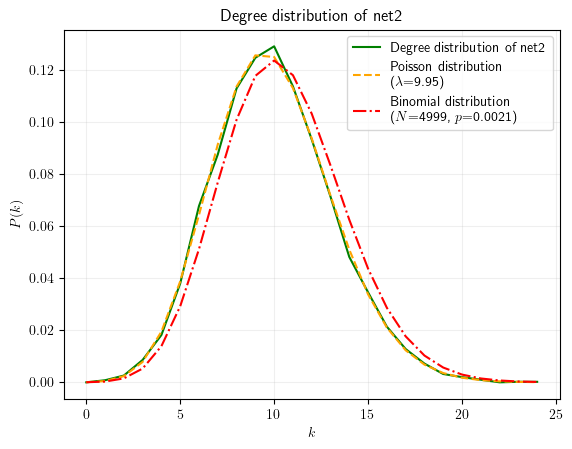

In [9]:
net2 = load_network("net2.net")
degree_sequence = list(dict(net2.degree()).values())
degree_pdf = np.bincount(degree_sequence) / len(degree_sequence)
plt.plot(degree_pdf, color="green", label="Degree distribution of net2")

# Plot a poisson pdf distribution with mean 9.9492
mean = 9.9492
x = np.arange(0, max(degree_sequence)+1)
poisson_dist = scipy.stats.poisson.pmf(x, mean)
plt.plot(x, poisson_dist, color="orange", linestyle="--", label=f"Poisson distribution\n($\lambda$={mean:.2f})")

# Plot a binomial with N = 4999 and p = 0.0021
N = 4999
p = 0.0021
binomial_dist = scipy.stats.binom.pmf(x, N, p)
plt.plot(x, binomial_dist, color="red", linestyle="-.", label=f"Binomial distribution\n($N$={N}, $p$={p:.4f})")

plt.legend()
plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title("Degree distribution of net2")
plt.grid(True, alpha=0.2)
plt.savefig(os.path.join(OUT_PATH, "net2_degree_poisson_binomial.png"), dpi=300)
plt.show()

### 2.3. Network 3: Configuration Model

Generating Configuration Model networks: 100%|██████████| 50/50 [09:29<00:00, 11.38s/it]


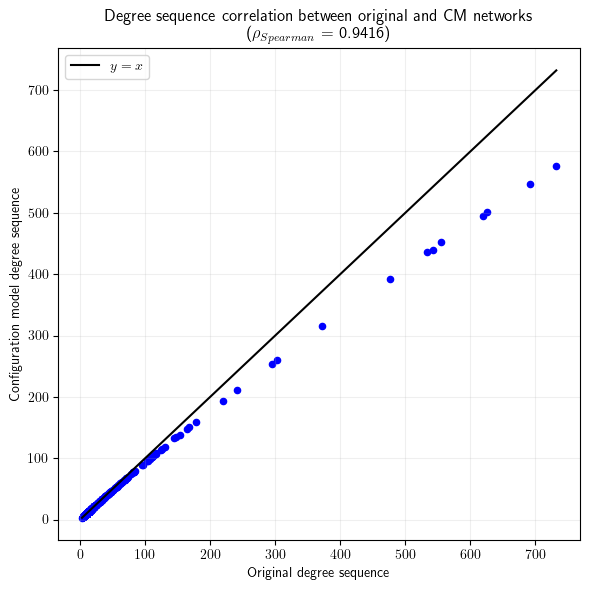

num_nodes: 5000.0000 ± 0.0000
num_edges: 22615.1400 ± 27.1006
max_degree: 575.4600 ± 11.1017
min_degree: 2.9800 ± 0.1400
avg_degree: 9.0461 ± 0.0108
avg_clustering: 0.0590 ± 0.0013
assortativity: -0.1023 ± 0.0014
aspl: 3.1395 ± 0.0055
diameter: 5.3000 ± 0.4583


In [10]:
net_3 = load_network("net3.net")
cm_simulation(list(dict(net_3.degree()).values()), num_trials=50)

Fitted power-law exponent (gamma): 2.3363


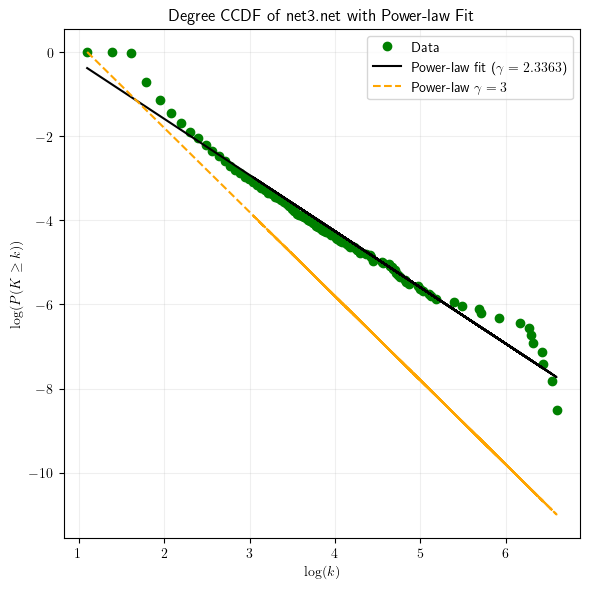

In [11]:
power_law("net3.net")

### 2.4. Network 4: Barabási-Albert Model

In [12]:
ba_simulation()

Generating Barabási-Albert networks: 100%|██████████| 50/50 [07:45<00:00,  9.32s/it]

num_nodes: 5000.0000 ± 0.0000
num_edges: 24975.0000 ± 0.0000
max_degree: 278.4800 ± 43.3683
min_degree: 4.9600 ± 0.2800
avg_degree: 9.9900 ± 0.0000
avg_clustering: 0.0120 ± 0.0008
assortativity: -0.0351 ± 0.0035
aspl: 3.4657 ± 0.0128
diameter: 5.0800 ± 0.2713


Fitted power-law exponent (gamma): 2.9610


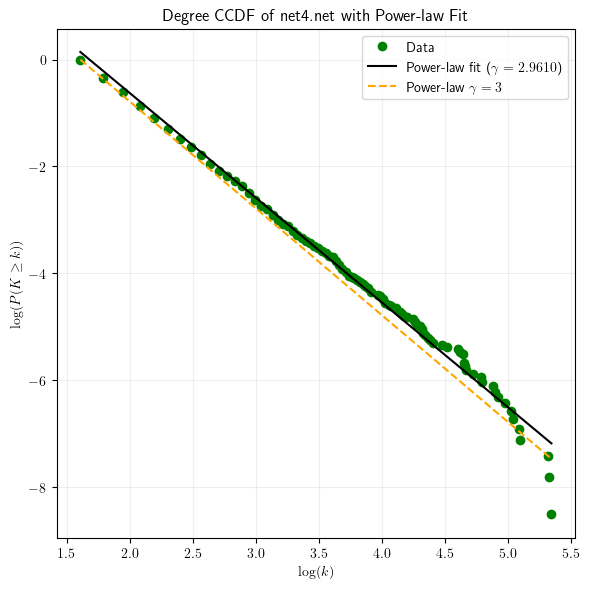

In [13]:
power_law("net4.net")

## 3. An extra network

In [14]:
net5 = nx.read_pajek(os.path.join(DATA_PATH, "net5.net"))
net5 = nx.Graph(net5)

print(f"Number of nodes in net5: {net5.number_of_nodes()}")
print(f"Number of edges in net5: {net5.number_of_edges()}")

with open(os.path.join(DATA_PATH, "positions_net5.txt"), "r") as f:
    positions = [line for line in f.read().split("\n")]

positions = {
    line.split("\t")[0]: [float(line.split("\t")[1]), float(line.split("\t")[2])] for line in positions[1:-1]
}

Number of nodes in net5: 200
Number of edges in net5: 465


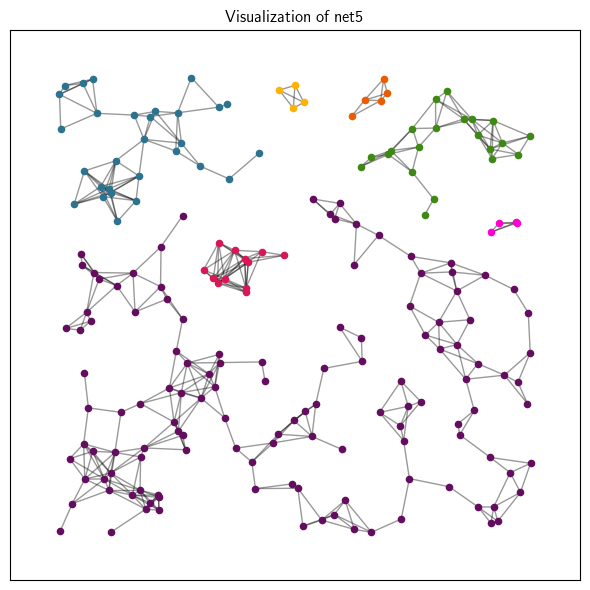

In [15]:
fig = plt.figure(figsize=(6, 6))
plt.title("Visualization of net5")
net_5_components = list(nx.connected_components(net5))


for i, component in enumerate(net_5_components):
    nx.draw_networkx_nodes(
        net5,
        positions,
        nodelist=list(component),
        node_size=20,
        node_color=colors[i],
    )
nx.draw_networkx_edges(net5, positions, alpha=0.4)
# nx.draw_networkx_labels(G, positions, font_size=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_PATH, "net5_visualization.png"), dpi=300)
plt.show()

In [16]:
print(f"Network connected: {nx.is_connected(net5)}")

Network connected: False


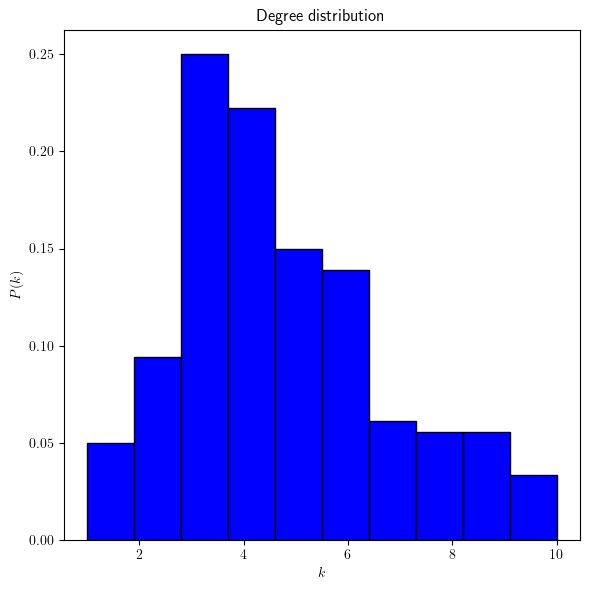

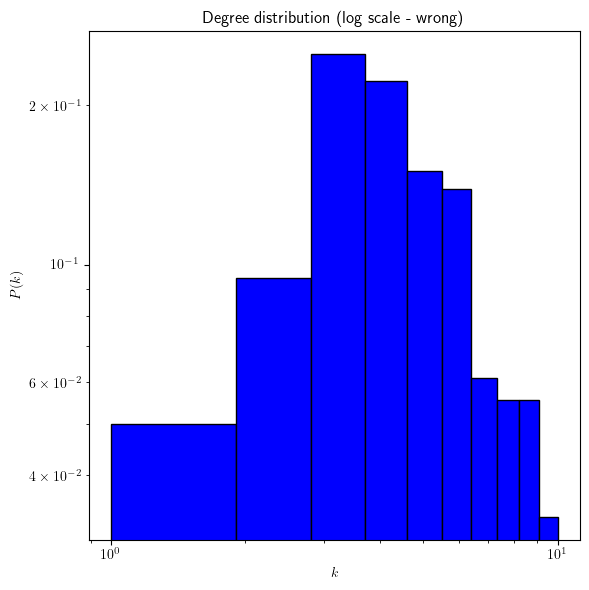

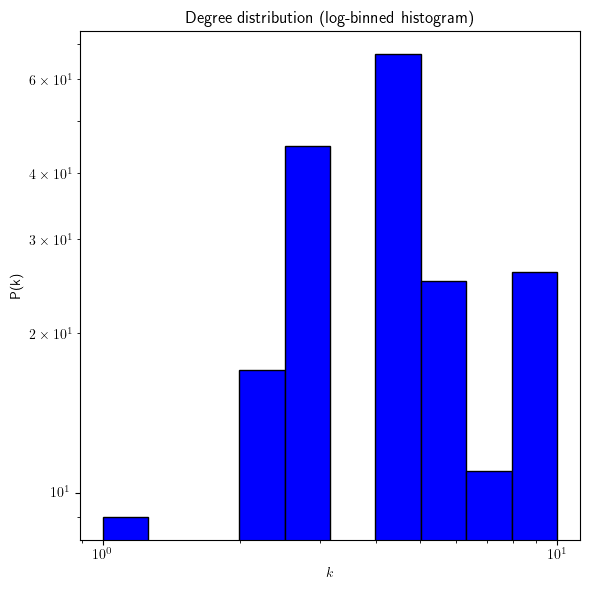

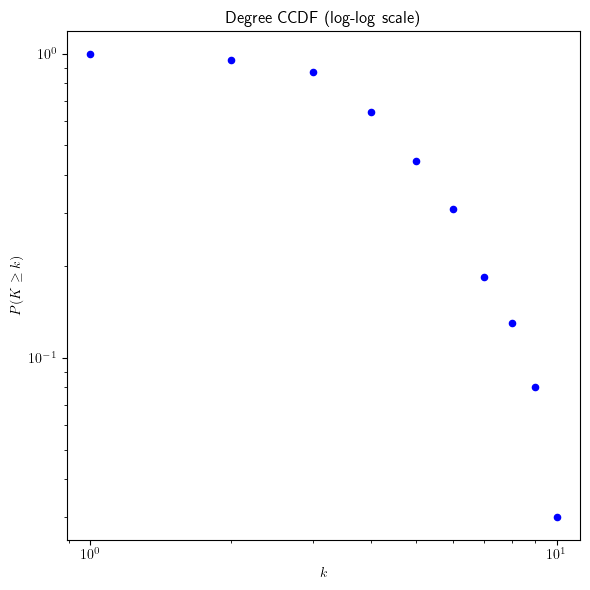

In [17]:
net_name = "net5"
degrees_net5 = list(dict(net5.degree()).values())

plot_degree_hist_wrong(degrees_net5, out_path=os.path.join(OUT_PATH, f"{net_name.replace('.', '')}_hist.png"), show_fig=True)
plot_degree_hist_wrong(degrees_net5, out_path=os.path.join(OUT_PATH, f"{net_name.replace('.', '')}_hist_log.png"), log_scale=True, show_fig=True)
plot_degree_hist_logbin(
    degrees_net5,
    out_path=os.path.join(OUT_PATH, f"{net_name.replace('.', '')}_hist_logbin.png"),
    show_fig=True
)

plot_degree_ccdf(
    degrees_net5,
    out_path=os.path.join(OUT_PATH, f"{net_name.replace('.', '')}_ccdf.png"),
    show_fig=True
)

In [18]:
print(f"Number of connected components: {len(net_5_components)}")
print(f"Size connected components: {[len(c) for c in net_5_components]}")
max_cc = max(net_5_components, key=len)
max_cc_graph = net5.subgraph(max_cc)

Number of connected components: 7
Size connected components: [125, 12, 5, 4, 29, 21, 4]


Number of nodes in the largest CC: 125
Number of edges in the largest CC: 275
Max degree in the largest CC: 10
Min degree in the largest CC: 1
Average degree in the largest CC: 4.4
Clustering coefficient of the largetst CC: 0.5475
Degree assortativity of the largest CC: 0.5373
Average shortest path length of the largest CC: 13.131
Diameter of the largest CC: 35


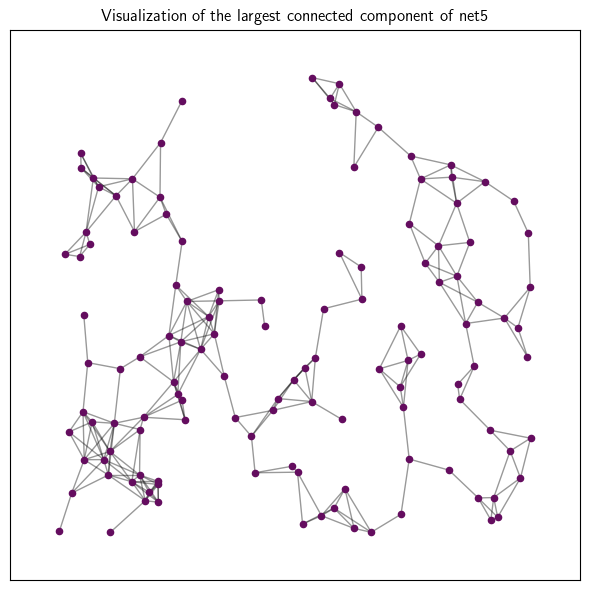

In [19]:
fig = plt.figure(figsize=(6, 6))
plt.title("Visualization of the largest connected component of net5")
nx.draw_networkx_nodes(
    max_cc_graph,
    positions,
    node_size=20,
    node_color=colors[0],
)
nx.draw_networkx_edges(max_cc_graph, positions, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUT_PATH, "net5_largest_cc_visualization.png"), dpi=300)


print(f"Number of nodes in the largest CC: {max_cc_graph.number_of_nodes()}")
print(f"Number of edges in the largest CC: {max_cc_graph.number_of_edges()}")
degree_list = list(dict(max_cc_graph.degree()).values())
print(f"Max degree in the largest CC: {max(degree_list)}")
print(f"Min degree in the largest CC: {min(degree_list)}")
print(f"Average degree in the largest CC: {round(np.mean(degree_list), 4)}")

print(f"Clustering coefficient of the largetst CC: {round(np.mean(list(nx.clustering(max_cc_graph).values())), 4)}")
print(f"Degree assortativity of the largest CC: {round(nx.degree_assortativity_coefficient(max_cc_graph), 4)}")
print(f"Average shortest path length of the largest CC: {round(nx.average_shortest_path_length(max_cc_graph), 4)}")
print(f"Diameter of the largest CC: {nx.diameter(max_cc_graph)}")

### 3.1. Random Geometric Graph

In [20]:
distances = []
for u, v in net5.edges():
    pos_u = np.array(positions[u])
    pos_v = np.array(positions[v])
    distance = np.linalg.norm(pos_u - pos_v) # Assume euclidean distance.
    distances.append(distance)
    
print(f"r: {max(distances):.4f}")

r: 0.0900


Number of connected components in the random geometric graph: 200


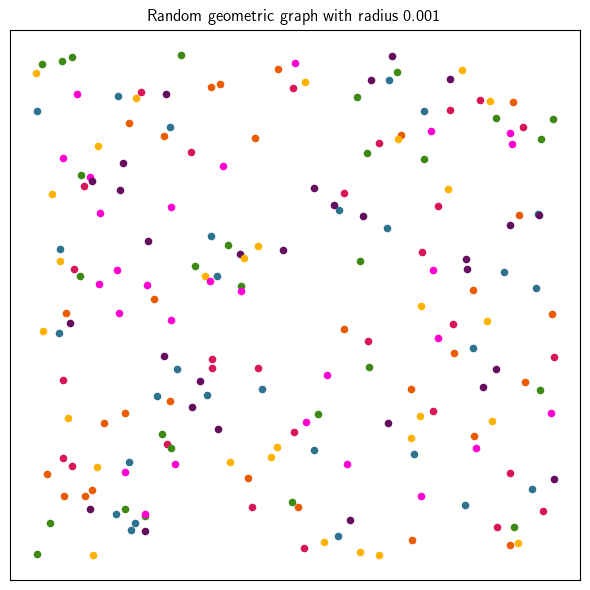

Number of connected components in the random geometric graph: 200


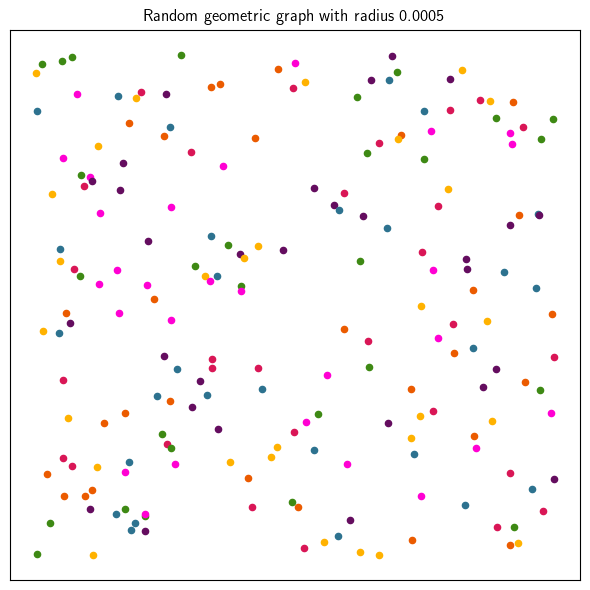

Number of connected components in the random geometric graph: 87


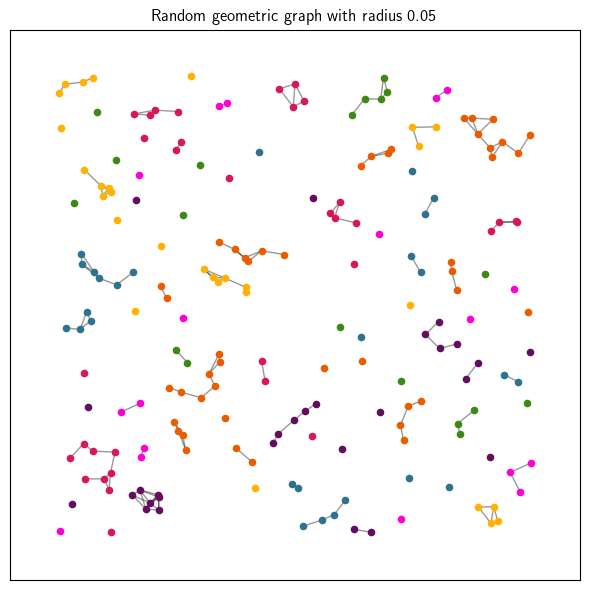

Number of connected components in the random geometric graph: 38


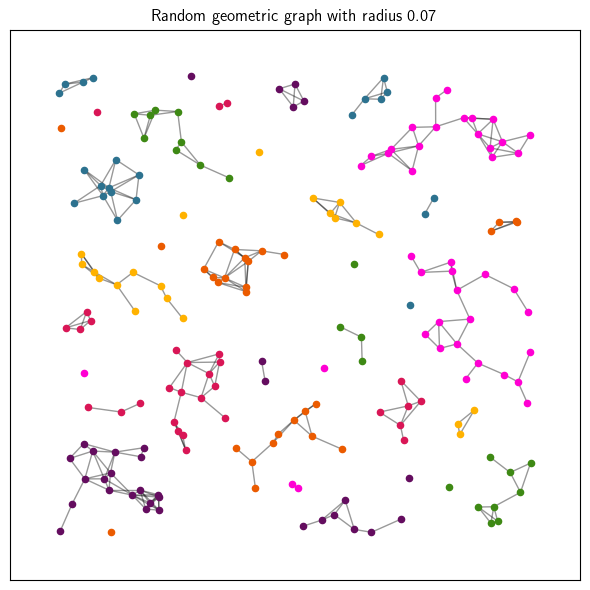

Number of connected components in the random geometric graph: 22


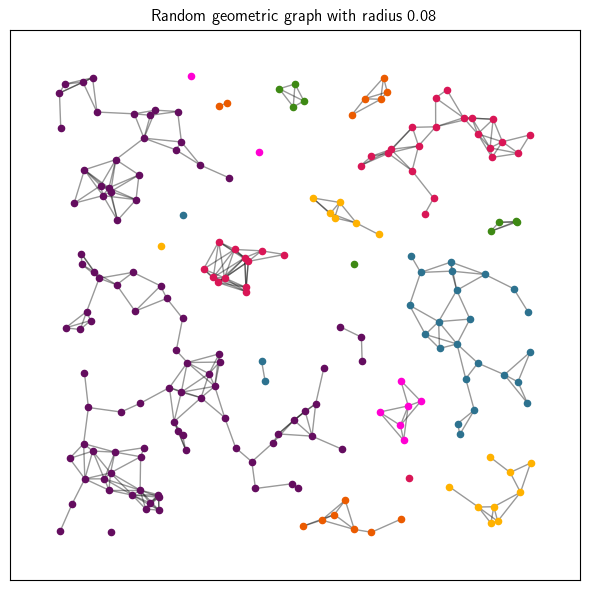

Number of connected components in the random geometric graph: 7


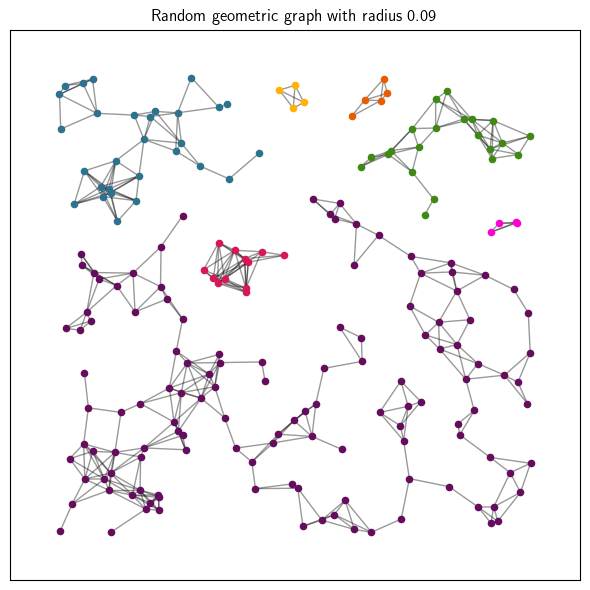

Number of connected components in the random geometric graph: 3


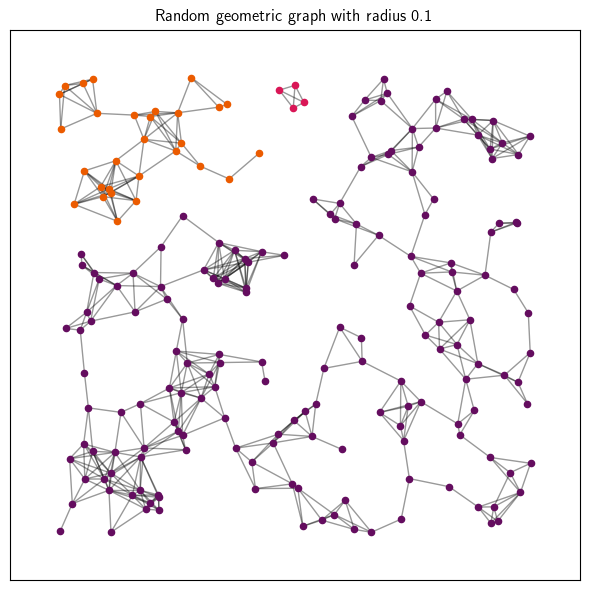

Number of connected components in the random geometric graph: 1


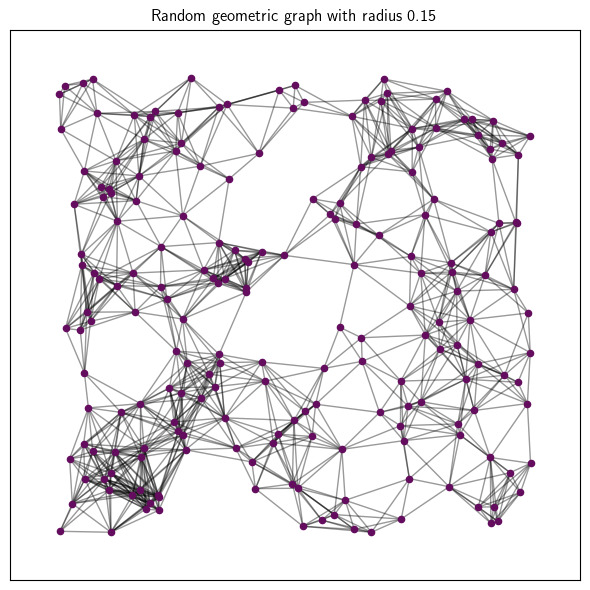

Number of connected components in the random geometric graph: 1


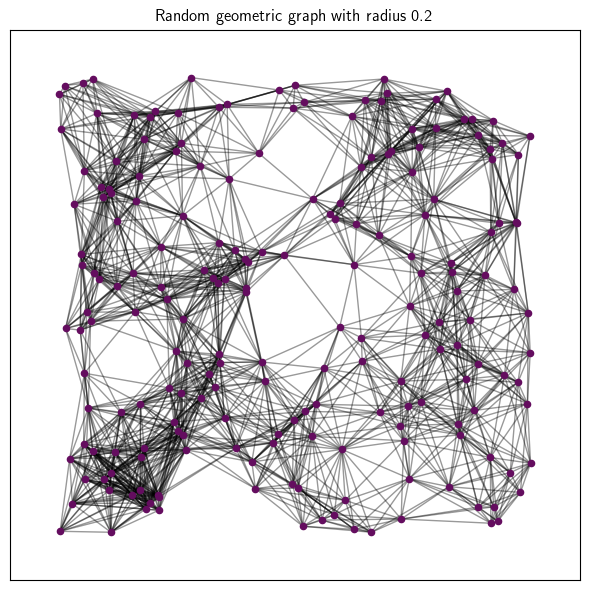

Number of connected components in the random geometric graph: 1


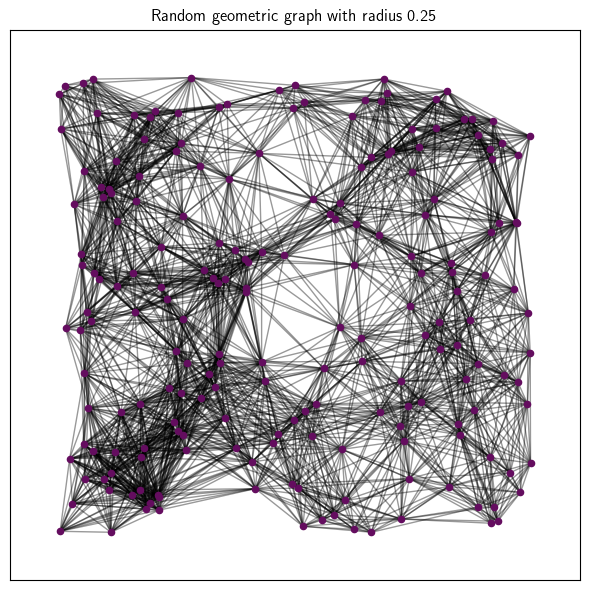

In [21]:
for radius in [0.001, 0.0005, 0.05, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2, 0.25]:
    random_geometric_graph_simulation(positions, radius=radius, show_fig=True)